In [1]:
!pip install diffusers transformers accelerate torch --quiet

## Load Stable Diffusion Model



In [2]:
import torch
from diffusers import StableDiffusionPipeline

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# Generate Creative Artwork

  0%|          | 0/50 [00:00<?, ?it/s]

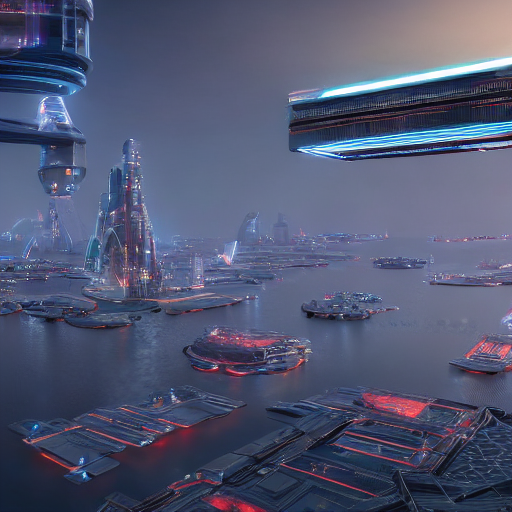

In [3]:
prompt = "A futuristic floating city in the sky, cyberpunk style, ultra detailed, 8k"

image = pipe(prompt).images[0]

image

# Try Different Creative Prompts




Guidance Scale Experiment (Model Sensitivity Study)

  0%|          | 0/50 [00:00<?, ?it/s]

Guidance Scale: 5


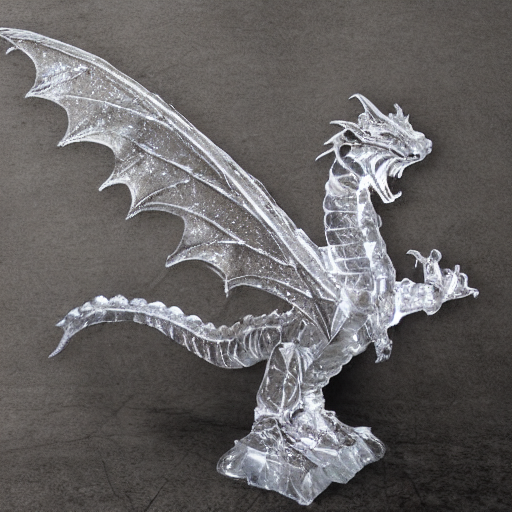

  0%|          | 0/50 [00:00<?, ?it/s]

Guidance Scale: 7.5


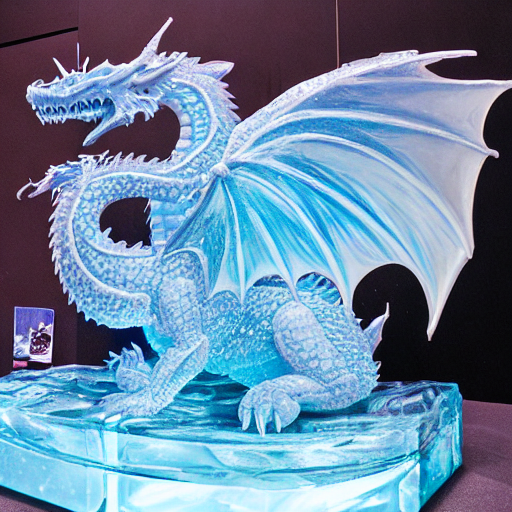

  0%|          | 0/50 [00:00<?, ?it/s]

Guidance Scale: 12


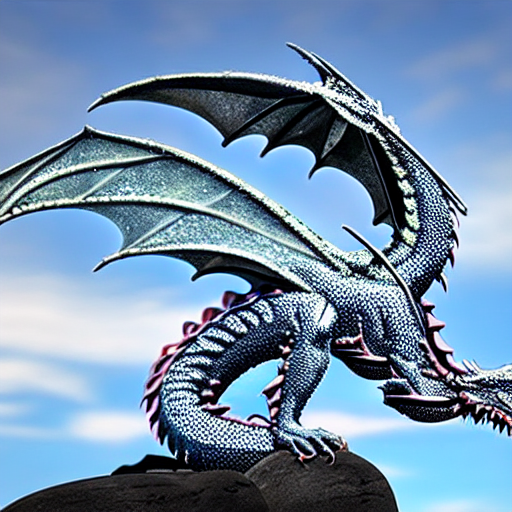

In [8]:
scales = [5, 7.5, 12]

prompt = "A dragon made of crystal ice"

for scale in scales:
    image = pipe(prompt, guidance_scale=scale).images[0]
    print(f"Guidance Scale: {scale}")
    display(image)

Random Seed Reproducibility

# Before & After Noise Visualization

  0%|          | 0/20 [00:00<?, ?it/s]

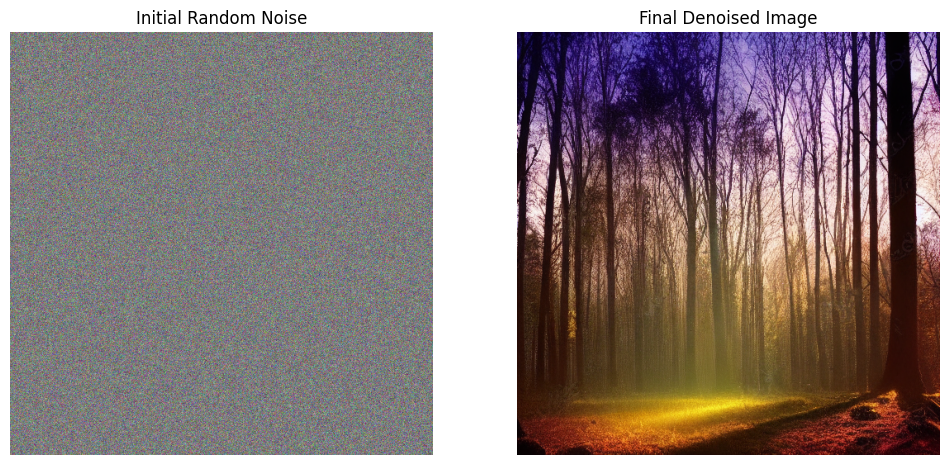

In [12]:
import matplotlib.pyplot as plt

prompt = "A mystical glowing forest at night, cinematic lighting"

# Fix seed for reproducibility
generator = torch.manual_seed(42)

# Generate with fewer steps for demonstration
num_steps = 20

images = pipe(
    prompt,
    num_inference_steps=num_steps,
    generator=generator,
    output_type="pil"
).images

final_image = images[0]

# Generate pure random noise manually
noise = torch.randn((1, 3, 512, 512)).cpu()
noise_image = noise.squeeze().permute(1, 2, 0).numpy()

# Normalize noise for visualization
noise_image = (noise_image - noise_image.min()) / (noise_image.max() - noise_image.min())

# Plot side by side
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.title("Initial Random Noise")
plt.imshow(noise_image)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Final Denoised Image")
plt.imshow(final_image)
plt.axis("off")

plt.show()

Side-by-side comparison grid visualization

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


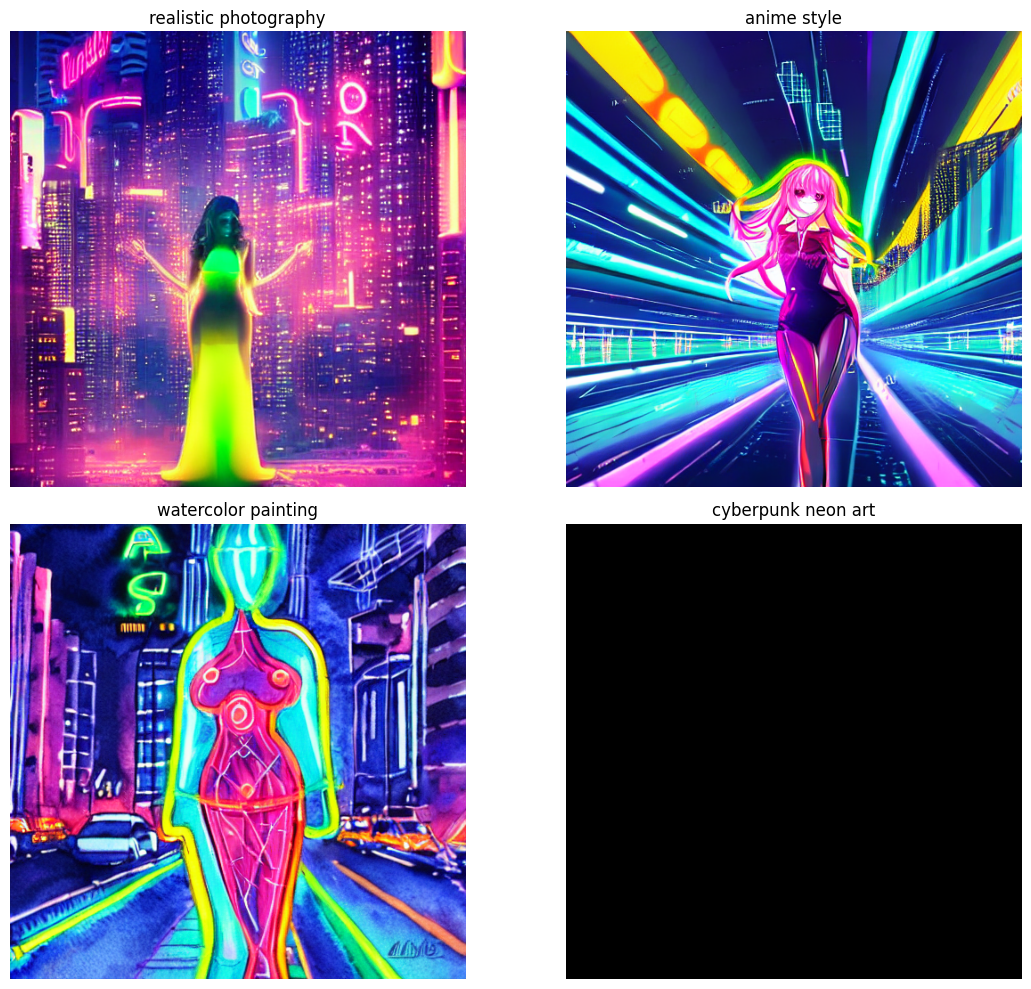

In [14]:
import torch
import matplotlib.pyplot as plt
from diffusers import StableDiffusionPipeline



# Base prompt
base_prompt = "A futuristic AI goddess standing in a neon city"

# Different styles
styles = [
    "realistic photography",
    "anime style",
    "watercolor painting",
    "cyberpunk neon art"
]

# Generate images
images = []
generator = torch.manual_seed(42)

for style in styles:
    prompt = f"{base_prompt}, {style}, ultra detailed"
    image = pipe(
        prompt,
        guidance_scale=8,
        generator=generator
    ).images[0]
    images.append(image)

# Plot grid
plt.figure(figsize=(12,10))

for i, img in enumerate(images):
    plt.subplot(2, 2, i+1)
    plt.imshow(img)
    plt.title(styles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()